# The ANI-1ccx dataset: coupled-cluster labels and transfer learning with the `ani-1ccx` preset

The **ANI-1ccx dataset** (Smith *et al.*, *Nat. Commun.* **10**, 2903, 2019;
released in *Sci. Data* **7**, 134, 2020) is the training set behind the
**ANI-1ccx** potential. It is an intelligently selected ~10 % subset of the
ANI-1x set, **recomputed at an approximate CCSD(T)/CBS level**: the
CCSD(T)\*/CBS composite scheme (DLPNO-CCSD(T) plus MP2/HF basis-set
extrapolation), ~50× cheaper than full CCSD(T)/CBS for an aspirin-size
molecule. Two things matter here:

- **Coupled-cluster energies, no forces.** CCSD(T)\*/CBS is the "gold
  standard" target; only energies were computed (~500 k of them).
- **Transfer learning.** The published ANI-1ccx model is the ANI-1x
  *architecture*, pre-trained on the ~5 M DFT energies+forces of ANI-1x and
  then fine-tuned on the ~500 k coupled-cluster energies.

Same one-line hub as every other dataset, and since ANI-1ccx lives inside the
same `ani1x-release.h5` file as ANI-1x (a conformation "is in" ANI-1ccx when
its `ccsd(t)_cbs.energy` was computed), the 5.6 GB download and cache are
**shared** with `load_dataset("ani1x")`:

```python
from xnns.common.data import load_dataset
cc = load_dataset("ani1ccx", split="train")   # CCSD(T)*/CBS energies, in eV
```

Here we load a small subset, pair every coupled-cluster conformation with its
DFT twin from `ani1x`, and mimic the paper's recipe in miniature: pre-train the
**`ani-1ccx` preset** on DFT energies+forces, fine-tune on the CCSD(T)\*/CBS
energies, and compare against training on the coupled-cluster data from
scratch. This completes the series `ani1_dataset.ipynb` →
`ani1x_dataset.ipynb` → this notebook.

Run with the **`xnns`** kernel.

## 0. Load the coupled-cluster subset, and its DFT twin

`ani1ccx` returns energy-only structures. Because it is a subset of the same
release file, every one of its conformations also appears in
`load_dataset("ani1x", level="wb97x_dz")` with DFT energy **and forces**; the
coordinates are bit-identical, so we can pair the two levels of theory exactly
and look at the gap the transfer learning has to close.

ani1ccx:ccsd(t)_cbs.energy:   0%|          | 0/150 [00:00<?, ? mol/s]

ani1x:wb97x_dz.energy:   0%|          | 0/150 [00:00<?, ? mol/s]

CCSD(T)*/CBS conformations: 2,456   DFT conformations: 81,119
E_CC - E_DFT per atom: 0.515 +- 0.058 eV
keys per CC structure: ['atomic_numbers', 'energy', 'pos']     # no forces


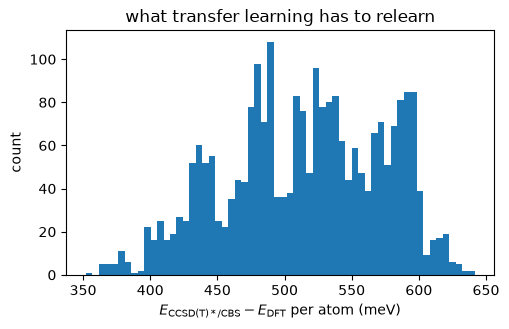

In [1]:
import time, warnings
warnings.filterwarnings("ignore")
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)
torch.manual_seed(0)

from xnns.common.data import load_dataset

N_MOL = 150
# coupled-cluster subset: energy-only (CCSD(T)*/CBS has no forces), eV
cc = load_dataset("ani1ccx", max_molecules=N_MOL, units="eV")["all"]
# the same molecules at the DFT level ANI-1x was trained on, with forces
dft = load_dataset("ani1x", max_molecules=N_MOL, level="wb97x_dz",
                   units="eV")["all"]
print(f"CCSD(T)*/CBS conformations: {len(cc):,}   DFT conformations: {len(dft):,}")

# pair each coupled-cluster conformation with its DFT twin (identical coords)
by_pos = {s["pos"].tobytes(): s for s in dft}
pairs = [(c, by_pos[c["pos"].tobytes()]) for c in cc]
assert len(pairs) == len(cc)          # ANI-1ccx is a strict subset of ANI-1x

dE = np.array([(c["energy"] - d["energy"]) / len(c["atomic_numbers"])
               for c, d in pairs])
print(f"E_CC - E_DFT per atom: {dE.mean():.3f} +- {dE.std():.3f} eV")
print(f"keys per CC structure: {sorted(cc[0])}     # no forces")

plt.figure(figsize=(5.2, 3.4))
plt.hist(dE * 1e3, bins=60)
plt.xlabel(r"$E_{\mathrm{CCSD(T)*/CBS}} - E_{\mathrm{DFT}}$ per atom (meV)")
plt.ylabel("count"); plt.title("what transfer learning has to relearn")
plt.tight_layout(); plt.show()

## 1. Self atomic energies and splits

The constant ~0.5 eV/atom offset between the two levels of theory is exactly
what per-element **self atomic energies** absorb, so we fit one set per level,
following the paper's linear-fitting procedure (its SI), which published separate
DFT and CCSD(T)\*/CBS parameters (the ones behind `ANI.ani1x()` and
`ANI.ani1ccx()`), and hand them to the model as `atomic_energies`. What is left for the fine-tuning to learn is the
*conformation-dependent* part of the CC-DFT difference (the ~60 meV/atom
spread above). We split the paired conformations 90/10; the coupled-cluster
**test** conformations are held out of *both* training stages.

In [2]:
SPECIES = [1, 6, 7, 8]

def fit_sae(structs):
    counts = np.array([[np.sum(s["atomic_numbers"] == z) for z in SPECIES]
                       for s in structs], float)
    E = np.array([s["energy"] for s in structs])
    return np.linalg.lstsq(counts, E, rcond=None)[0]

rng = np.random.default_rng(0)
idx = rng.permutation(len(pairs)); ncut = int(0.9 * len(pairs))
cc_train = [pairs[i][0] for i in idx[:ncut]]
cc_test = [pairs[i][0] for i in idx[ncut:]]
test_keys = {s["pos"].tobytes() for s in cc_test}

# DFT pre-training pool: everything ani1x gave us for these molecules, minus
# the held-out coupled-cluster test conformations, subsampled for the demo
pool = [d for d in dft if d["pos"].tobytes() not in test_keys]
dft_train = [pool[i] for i in rng.permutation(len(pool))[:8000]]

sae_dft, sae_cc = fit_sae(dft_train), fit_sae(cc_train)
print("SAE DFT (eV):", {z: round(float(e), 2) for z, e in zip(SPECIES, sae_dft)})
print("SAE CC  (eV):", {z: round(float(e), 2) for z, e in zip(SPECIES, sae_cc)})
print(f"DFT pre-train {len(dft_train):,}   CC fine-tune {len(cc_train):,}   CC test {len(cc_test):,}")

SAE DFT (eV): {1: -16.42, 6: -1036.0, 7: -1490.07, 8: -2047.0}
SAE CC  (eV): {1: -16.68, 6: -1034.47, 7: -1489.3, 8: -2046.13}
DFT pre-train 8,000   CC fine-tune 2,210   CC test 246


## 2. Transfer learning: DFT pre-training, coupled-cluster retraining

The **`ani-1ccx` preset** is the ANI-1x architecture (384-length AEV,
per-element widths, `CELU`); the two published models differ only in training
data and self energies, and `ANI.ani1ccx()` simply reuses `ANI.ani1x()` with
the coupled-cluster self energies. We follow the paper's recipe (its Fig. 4)
in miniature:

1. **Pre-train** on DFT energies *and forces* (`force_weight > 0`; the force
   labels are why the DFT stage teaches so much more per conformation);
2. **Retrain** the same weights on the CCSD(T)\*/CBS energies with part of
   each element network **held fixed** to avoid overfitting the smaller
   coupled-cluster set, and the coupled-cluster self energies swapped in. The
   paper's Methods pin this down precisely: "65,280 of the 325,248 optimizable
   neural network parameters held constant". Decomposing those counts against
   the Table-S2 architecture, 325,248 is the total *weight* count (biases
   excluded) and 65,280 is **exactly the weight matrix joining hidden layers
   1 and 2** of each element network, the unique layer combination that
   matches, and the paper's "two fixed hidden layers". That is what we freeze.
3. and, for contrast, train an identical model on the coupled-cluster
   energies only, the paper's **ANI-1ccx-R** control.

As in the paper's SI, every stage uses the same optimizer settings: Adam,
initial learning rate 1e-3, annealed on plateau. (The paper also evaluates
Δ-learning, a second network trained on the CC−DFT difference, which
matches transfer learning's accuracy but costs two evaluations.)

In [3]:
from xnns.common.data import AtomicDataset
from xnns.common.config import Config, ModelConfig, DataConfig, OptimConfig
from xnns.common.train import Trainer

CUTOFF, BS = 5.2, 64

def make_trainer(structs, sae, out, lr, epochs, force_weight):
    cfg = Config(
        model=ModelConfig(name="ani", cutoff=CUTOFF,
                          extra={"preset": "ani-1ccx", "species": SPECIES,
                                 "atomic_energies": sae.tolist()}),
        data=DataConfig(cutoff=CUTOFF, batch_size=BS),  # val_fraction 0.1 carves val
        optim=OptimConfig(lr=lr, epochs=epochs, energy_weight=1.0,
                          force_weight=force_weight, scheduler="plateau"),
        output_dir=f"runs/{out}",
    )
    return Trainer(cfg, AtomicDataset(structs, CUTOFF))

# stage 1: pre-train on DFT energies + forces
pre = make_trainer(dft_train, sae_dft, "ani1ccx_pretrain", 1e-3, 60, 10.0)
print(f"parameters: {sum(p.numel() for p in pre.module.parameters()):,}  device {pre.device}")
t0 = time.time(); pre.fit()
print(f"pre-trained on DFT in {time.time()-t0:.0f}s")

# stage 2: retrain on CCSD(T)*/CBS energies -- transplant everything except
# the self-energy buffer, which switches from the DFT to the CC linear fit
tune = make_trainer(cc_train, sae_cc, "ani1ccx_transfer", 1e-3, 80, 0.0)
weights = {k: v for k, v in pre.module.state_dict().items()
           if "_self_energies" not in k}
tune.module.load_state_dict(weights, strict=False)
zero_shot = make_trainer(cc_train, sae_cc, "ani1ccx_zeroshot", 1e-3, 1, 0.0)
zero_shot.module.load_state_dict(tune.module.state_dict())   # pre-retrain copy

# hold constant what the paper holds constant: 65,280 of the 325,248 network
# weights -- exactly the matrix joining hidden layers 1 and 2 of each element
# network (see the markdown above for the derivation)
n_frozen = n_weights = 0
for net in tune.module.model.element_nets.nets.values():
    linears = [l for l in net if isinstance(l, torch.nn.Linear)]
    n_weights += sum(l.weight.numel() for l in linears)
    l2 = linears[1]
    l2.weight.requires_grad_(False); l2.bias.requires_grad_(False)
    n_frozen += l2.weight.numel()
print(f"held fixed: {n_frozen:,} of {n_weights:,} weights (paper: 65,280 of 325,248)")
assert (n_frozen, n_weights) == (65280, 325248)
t0 = time.time(); tune.fit()
print(f"retrained on CC in {time.time()-t0:.0f}s")

# ANI-1ccx-R control: same architecture trained on the CC energies only
ccx_r = make_trainer(cc_train, sae_cc, "ani1ccx_r", 1e-3, 140, 0.0)
t0 = time.time(); ccx_r.fit()
print(f"ANI-1ccx-R (CC only, no transfer) trained in {time.time()-t0:.0f}s")

parameters: 326,660  device cuda


epoch    0 | train loss 1.2438e+01 | val loss 4.0926e+00


epoch    1 | train loss 2.6904e+00 | val loss 2.0254e+00


epoch    2 | train loss 1.6905e+00 | val loss 1.6604e+00


epoch    3 | train loss 1.3297e+00 | val loss 1.2682e+00


...

epoch  135 | train loss 1.2538e-04 | val loss 6.3451e-04


epoch  136 | train loss 1.2529e-04 | val loss 6.3449e-04


epoch  137 | train loss 1.2518e-04 | val loss 6.3448e-04


epoch  138 | train loss 1.2821e-04 | val loss 6.3447e-04


epoch  139 | train loss 1.2584e-04 | val loss 6.3445e-04
ANI-1ccx-R (CC only, no transfer) trained in 63s


## 3. Parity against CCSD(T)\*/CBS on held-out conformations

Three models, one test set of coupled-cluster energies: the DFT-pre-trained
model *before* retraining ("zero-shot", only the self energies adjusted, the
analogue of evaluating ANI-1x against coupled-cluster references), the
CC-only **ANI-1ccx-R** control, and the transfer-learned **ANI-1ccx**-style
model. The paper's point in miniature, and the same ordering as its Table 1
(ANI-1ccx 2.07 < ANI-1ccx-R 2.54 < ANI-1x 2.79 kcal/mol RMSD on
GDB-10to13): the coupled-cluster data alone is too scarce, but a model that
already knows the DFT potential-energy surface only needs a small
correction.

zero-shot (DFT weights)    CC test energy RMSE:  1443.5 meV =  33.29 kcal/mol
ANI-1ccx-R (CC only)       CC test energy RMSE:   555.6 meV =  12.81 kcal/mol
transfer-learned           CC test energy RMSE:   218.8 meV =   5.05 kcal/mol


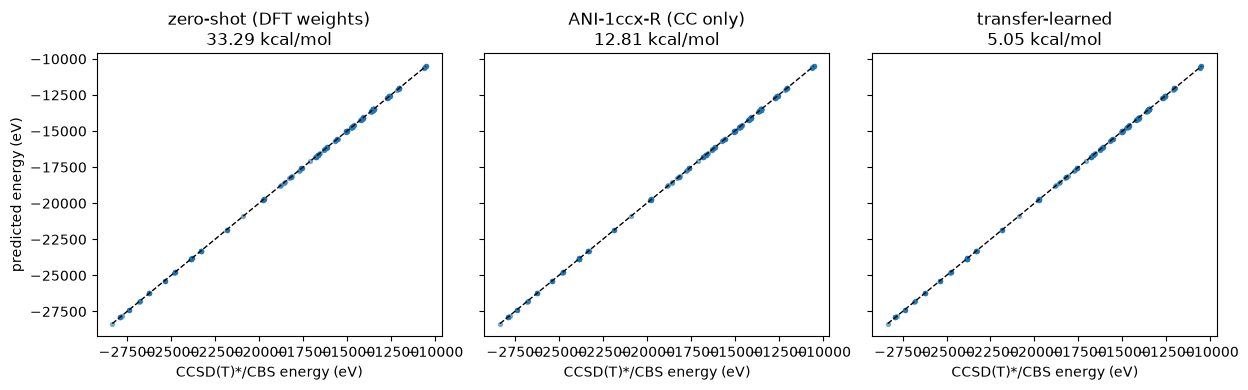

In [4]:
from torch.utils.data import DataLoader
from xnns.common.data import collate

EV2KCAL = 23.060541945329334
test_ds = AtomicDataset(cc_test, CUTOFF)

def energies(trainer):
    model = trainer.model.eval(); device = trainer.device
    pred, ref = [], []
    for batch in DataLoader(test_ds, batch_size=64, collate_fn=collate):
        batch = batch.to(device)
        pred.append(model(batch)["energy"].detach().cpu().numpy())
        ref.append(batch.energy.cpu().numpy())
    return np.concatenate(pred), np.concatenate(ref)

results = {}
for name, tr in [("zero-shot (DFT weights)", zero_shot),
                 ("ANI-1ccx-R (CC only)", ccx_r),
                 ("transfer-learned", tune)]:
    pred, ref = energies(tr)
    rmse = np.sqrt(np.mean((pred - ref) ** 2))
    results[name] = (pred, ref, rmse)
    print(f"{name:26s} CC test energy RMSE: {rmse*1e3:7.1f} meV = {rmse*EV2KCAL:6.2f} kcal/mol")

fig, axes = plt.subplots(1, 3, figsize=(12.6, 4.0), sharex=True, sharey=True)
for ax, (name, (pred, ref, rmse)) in zip(axes, results.items()):
    ax.scatter(ref, pred, s=8, alpha=0.5)
    lim = [ref.min(), ref.max()]
    ax.plot(lim, lim, "k--", lw=1)
    ax.set_xlabel("CCSD(T)*/CBS energy (eV)")
    ax.set_title(f"{name}\n{rmse*EV2KCAL:.2f} kcal/mol")
axes[0].set_ylabel("predicted energy (eV)")
fig.tight_layout(); fig.savefig("ani1ccx_transfer.png", dpi=110); plt.show()

## Summary

`load_dataset("ani1ccx", ...)` brings the ~500 k-conformation coupled-cluster
training set into the hub under its own name: a strict subset of the ANI-1x
release, so the 5.6 GB file is downloaded and cached **once** for both. Paired
with the **`ani-1ccx` preset** (`ANI.ani1ccx()`, the ANI-1x architecture with
coupled-cluster self energies), it reproduces the published model's setup:
DFT pre-training on `ani1x`, coupled-cluster fine-tuning on `ani1ccx`.

The full family, side by side:

| | ANI-1 (`ani1`) | ANI-1x (`ani1x`) | ANI-1ccx (`ani1ccx`) |
|---|---|---|---|
| labels | DFT energies | DFT energies **+ forces** | **CCSD(T)\*/CBS** energies |
| size | ~20 M | ~5 M | ~500 k |
| sampling | dense Normal-Mode | active learning | active sub-sampling of ANI-1x |
| preset | `ANI.ani1()` | `ANI.ani1x()` | `ANI.ani1ccx()` (= ANI-1x arch.) |
| training | direct | direct | **transfer learning** from ANI-1x |

The relative ordering above (transfer-learned best, the CC-only ANI-1ccx-R
control worse, the DFT model worst against coupled-cluster references)
reproduces the paper's central result (its Table 1), here at demo scale. For the **pretrained** ANI-1x/ANI-1ccx weights transplanted from
torchani (rather than trained here), see
`examples/fidelity_checks/ani_verification.ipynb` and the parity tests in
`tests/test_ani.py`.